# code for assignment3


## 1) Setup and paths
Load packages, define paths, plotting defaults, and a small LaTeX-table helper.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve directories relative to this notebook.
ROOT = Path.cwd()
if ROOT.name == "Assignment3":
    ASSIGNMENT_DIR = ROOT
else:
    ASSIGNMENT_DIR = ROOT / "Assignment3"

TABLE_DIR = ASSIGNMENT_DIR / "tables"
FIGURE_DIR = ASSIGNMENT_DIR / "figures"
DATA_PATH = ASSIGNMENT_DIR / "Assignment_3.xlsx"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
})


def write_table(df, path, caption, label, index_name=None, float_format="%.4f"):
    """Render a DataFrame as a `[H]`-placed LaTeX table with a proper index header.

    Avoids pandas' to_latex multi-row header quirk by emitting plain tabular code.
    Numeric ints (columns of integer dtype) are emitted without decimals; floats
    use ``float_format``; strings pass through unchanged.
    """
    df = df.copy()
    if index_name is not None:
        df.index.name = index_name
    idx_label = df.index.name if df.index.name is not None else ""

    ncols = df.shape[1]
    col_spec = "l" + "r" * ncols

    col_is_int = {c: pd.api.types.is_integer_dtype(df[c]) for c in df.columns}

    def fmt(col, v):
        if isinstance(v, str):
            return v
        if v is None:
            return ""
        try:
            if pd.isna(v):
                return ""
        except (TypeError, ValueError):
            pass
        if col_is_int.get(col, False):
            return str(int(v))
        if isinstance(v, (int, np.integer)):
            return str(int(v))
        return float_format % float(v)

    lines = []
    lines.append("\\begin{table}[H]")
    lines.append("\\centering")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    lines.append("\\toprule")
    lines.append(idx_label + " & " + " & ".join(str(c) for c in df.columns) + " \\\\")
    lines.append("\\midrule")
    for idx, row in df.iterrows():
        cells_str = [fmt(col, row[col]) for col in df.columns]
        lines.append(f"{idx} & " + " & ".join(cells_str) + " \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    body = "\n".join(lines) + "\n"
    with open(path, "w", encoding="utf-8") as f:
        f.write(body)


print(f"Data path: {DATA_PATH}")
print(f"Table dir: {TABLE_DIR}")
print(f"Figure dir: {FIGURE_DIR}")

Data path: /Users/user/Projects/Econometrics-II/Assignment3/Assignment_3.xlsx
Table dir: /Users/user/Projects/Econometrics-II/Assignment3/tables
Figure dir: /Users/user/Projects/Econometrics-II/Assignment3/figures


## 2) Load and prepare data
Read the assignment data and keep the analysis window January 2012 to December 2023. The full sample 2000M1--2023M12 is retained separately for the later robustness check.

In [2]:
def _find_date_column(columns):
    for c in columns:
        c_low = str(c).strip().lower()
        if c_low in {"date", "month", "time", "period"}:
            return c
    return None

raw = pd.read_excel(DATA_PATH)
raw.columns = [str(c).strip() for c in raw.columns]

date_col = _find_date_column(raw.columns)
if date_col is not None:
    raw[date_col] = pd.to_datetime(raw[date_col])
    raw = raw.set_index(date_col)
else:
    raw.index = pd.date_range(start="2000-01-01", periods=len(raw), freq="MS")

raw = raw.sort_index()
df_full = raw.copy()
df = raw.loc["2012-01-01":"2023-12-01"].copy()

print("Main sample shape:", df.shape, "range:", df.index.min().date(), "to", df.index.max().date())
print("Full sample shape:", df_full.shape, "range:", df_full.index.min().date(), "to", df_full.index.max().date())
df.head()

Main sample shape: (144, 7) range: 2012-01-01 to 2023-12-01
Full sample shape: (300, 7) range: 2000-01-01 to 2024-12-01


,Unnamed: 0,HousePrice,Rent,MortgageRate,h,r,m
Date,,,,,,,
2012-01-01,2012(1),136.595,257.267,3.92,4.917020,5.550114,3.92
2012-02-01,2012(2),136.521,257.842,3.89,4.916478,5.552347,3.89
2012-03-01,2012(3),137.893,258.335,3.95,4.926478,5.554257,3.95
2012-04-01,2012(4),139.143,258.977,3.91,4.935502,5.556739,3.91
2012-05-01,2012(5),140.144,259.481,3.80,4.942670,5.558683,3.80


## 3) Descriptive statistics
Compact summary for the three analysis variables.

In [3]:
summary_vars = ["h", "r", "m"]
summary = df[summary_vars].describe().T[["mean", "std", "min", "max"]].copy()
summary.columns = ["Mean", "Std. Dev.", "Min", "Max"]

write_table(
    summary,
    TABLE_DIR / "table1_summary_stats.tex",
    caption="Summary statistics for the analysis variables, 2012M1--2023M12.",
    label="tab:summary_stats",
    index_name="Variable",
)
print("Saved:", TABLE_DIR / "table1_summary_stats.tex")
summary

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table1_summary_stats.tex


,Mean,Std. Dev.,Min,Max
h,5.310791,0.240209,4.916478,5.752677
r,5.751149,0.128742,5.550114,6.016538
m,4.164167,1.069064,2.680000,7.620000


## 4) Main data figure
Plot the three core variables used in the assignment equation.

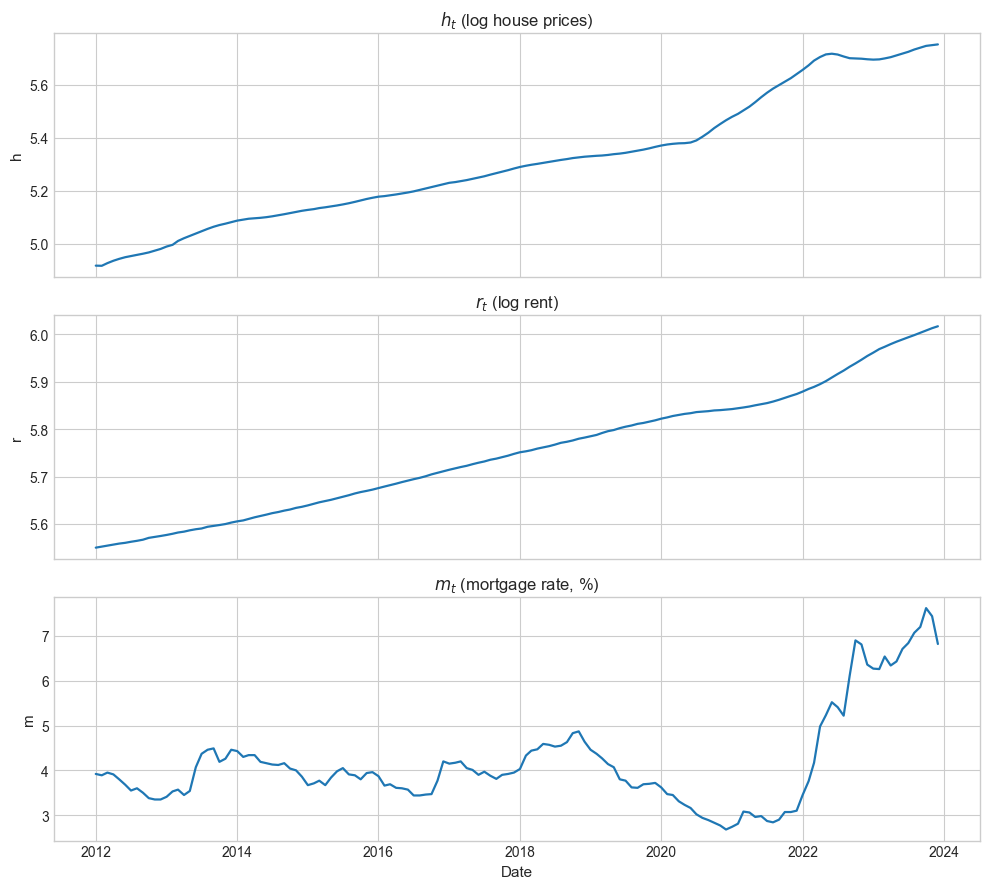

Saved: /Users/user/Projects/Econometrics-II/Assignment3/figures/fig1_series_panel.pdf


In [4]:
plot_cols = ["h", "r", "m"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
labels = {"h": "$h_t$ (log house prices)", "r": "$r_t$ (log rent)", "m": "$m_t$ (mortgage rate, %)"}
for i, c in enumerate(plot_cols):
    axes[i].plot(df.index, df[c], lw=1.6)
    axes[i].set_title(labels[c])
    axes[i].set_ylabel(c)

axes[-1].set_xlabel("Date")
fig.tight_layout()

fig1_path = FIGURE_DIR / "fig1_series_panel.pdf"
fig.savefig(fig1_path, bbox_inches="tight")
plt.show()
print("Saved:", fig1_path)

## 5) Unit-root testing (ADF)
ADF tests in levels and first differences as preliminary motivation for the I(1) assumption.

In [5]:
from statsmodels.tsa.stattools import adfuller

core = df[["h", "r", "m"]].copy()

rows = []
for name in core.columns:
    lvl = adfuller(core[name], autolag="AIC", regression="c")
    d1 = adfuller(core[name].diff().dropna(), autolag="AIC", regression="c")
    rows.append({
        "Stat. (lvl)": lvl[0],
        "p (lvl)": lvl[1],
        "Lags (lvl)": int(lvl[2]),
        "Stat. ($\\Delta$)": d1[0],
        "p ($\\Delta$)": d1[1],
        "Lags ($\\Delta$)": int(d1[2]),
    })

unit_root_table = pd.DataFrame(rows, index=["$h_t$", "$r_t$", "$m_t$"])
unit_root_table["Lags (lvl)"] = unit_root_table["Lags (lvl)"].astype(int)
unit_root_table["Lags ($\\Delta$)"] = unit_root_table["Lags ($\\Delta$)"].astype(int)
write_table(
    unit_root_table,
    TABLE_DIR / "table2_unit_root_tests.tex",
    caption="ADF unit-root tests with constant; lag length chosen by AIC.",
    label="tab:unit_root_tests",
    index_name="Variable",
)
print("Saved:", TABLE_DIR / "table2_unit_root_tests.tex")
unit_root_table

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table2_unit_root_tests.tex


,Stat. (lvl),p (lvl),Lags (lvl),Stat. ($\Delta$),p ($\Delta$),Lags ($\Delta$)
$h_t$,0.267912,0.975823,14,-3.215974,0.019078,1
$r_t$,1.725148,0.998188,12,-2.629625,0.087028,8
$m_t$,-1.625531,0.469831,5,-3.655491,0.004785,4


## 6) VAR lag selection on levels
Use information criteria as the first guide for the dynamic specification.

In [6]:
from statsmodels.tsa.api import VAR

var_model = VAR(core)
lag_order = var_model.select_order(maxlags=12)

criteria_table = pd.DataFrame({
    "AIC": lag_order.ics["aic"],
    "BIC": lag_order.ics["bic"],
    "HQIC": lag_order.ics["hqic"],
})
criteria_table.index = criteria_table.index.astype(int)

k_ar = int(lag_order.selected_orders.get("aic", 2))
k_ar = max(k_ar, 2)
k_ar_diff = k_ar - 1

write_table(
    criteria_table,
    TABLE_DIR / "table3_lag_selection.tex",
    caption="Lag-order selection criteria for VAR in levels (2012M1--2023M12).",
    label="tab:lag_selection",
    index_name="Lag",
    float_format="%.4f",
)
print(f"Selected k_ar (levels VAR): {k_ar}; k_ar_diff for VECM: {k_ar_diff}")
print("Saved:", TABLE_DIR / "table3_lag_selection.tex")
criteria_table.head(12)

Selected k_ar (levels VAR): 4; k_ar_diff for VECM: 3
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table3_lag_selection.tex


/Users/user/Projects/Econometrics-II/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,AIC,BIC,HQIC
0,-10.339068,-10.273550,-10.312445
1,-29.014597,-28.752524,-28.908103
2,-30.703502,-30.244874,-30.517137
3,-30.907671,-30.252488,-30.641435
4,-31.149764,-30.298027,-30.803657
5,-31.113787,-30.065496,-30.687810
6,-31.075776,-29.830930,-30.569928
7,-31.053623,-29.612222,-30.467904
8,-31.004179,-29.366223,-30.338589
9,-31.086363,-29.251853,-30.340903


## 7) Johansen rank testing and CVAR estimation
Determine the co-integration rank, estimate the preferred VECM, and extract standard errors.

In [7]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# det_order=0 includes an unrestricted constant in the Johansen setup.
joh = coint_johansen(core, det_order=0, k_ar_diff=k_ar_diff)

joh_table = pd.DataFrame({
    "Trace stat.": joh.lr1,
    "CV 90\\%": joh.cvt[:, 0],
    "CV 95\\%": joh.cvt[:, 1],
    "CV 99\\%": joh.cvt[:, 2],
}, index=["$r=0$", "$r\\leq 1$", "$r\\leq 2$"])

rank = 0
for i in range(len(joh.lr1)):
    if joh.lr1[i] > joh.cvt[i, 1]:
        rank = i + 1
rank = min(max(rank, 1), core.shape[1] - 1)

write_table(
    joh_table,
    TABLE_DIR / "table4_johansen_trace.tex",
    caption="Johansen trace test. Sequential procedure rejects if trace stat. exceeds the 5\\% critical value.",
    label="tab:johansen_trace",
    index_name="$H_0$",
)
print(f"Selected co-integration rank: {rank}")
print("Saved:", TABLE_DIR / "table4_johansen_trace.tex")
joh_table

Selected co-integration rank: 1
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table4_johansen_trace.tex


,Trace stat.,CV 90\%,CV 95\%,CV 99\%
$r=0$,48.226551,27.0669,29.7961,35.4628
$r\leq 1$,11.564844,13.4294,15.4943,19.9349
$r\leq 2$,3.620660,2.7055,3.8415,6.6349


In [8]:
vecm = VECM(core, k_ar_diff=k_ar_diff, coint_rank=rank, deterministic="co")
vecm_res = vecm.fit()

# Use statsmodels' normalised beta (first entry = 1 by construction in statsmodels).
beta = vecm_res.beta[:, 0]
alpha = vecm_res.alpha[:, 0]
se_beta = vecm_res.stderr_beta[:, 0]
se_alpha = vecm_res.stderr_alpha[:, 0]

# Implied elasticities (sign-flipped because the cointegrating relation is
#   h - beta_r * r - beta_m * m = stationary deviation).
beta_r = -beta[1]
beta_m = -beta[2]
se_beta_r = se_beta[1]
se_beta_m = se_beta[2]

est_rows = pd.DataFrame({
    "Estimate": [beta_r, beta_m, alpha[0], alpha[1], alpha[2]],
    "Std. err.": [se_beta_r, se_beta_m, se_alpha[0], se_alpha[1], se_alpha[2]],
}, index=[
    "$\\beta_r$ (rent elasticity)",
    "$\\beta_m$ (mortgage coef.)",
    "$\\alpha_h$",
    "$\\alpha_r$",
    "$\\alpha_m$",
])

write_table(
    est_rows,
    TABLE_DIR / "table5_cvar_estimates.tex",
    caption="Preferred CVAR (k=4, unrestricted constant, rank 1). Normalised on $h_t$. Std. err.\\ from VECM ML.",
    label="tab:cvar_estimates",
    index_name="Parameter",
)
print(f"beta_r = {beta_r:.4f} (s.e. {se_beta_r:.4f}); beta_m = {beta_m:.4f} (s.e. {se_beta_m:.4f})")
print(f"alpha = {alpha}")
print("Saved:", TABLE_DIR / "table5_cvar_estimates.tex")
est_rows

beta_r = 1.4918 (s.e. 0.0467); beta_m = 0.0085 (s.e. 0.0068)
alpha = [0.01562666 0.00908112 0.39576822]
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table5_cvar_estimates.tex


/Users/user/Projects/Econometrics-II/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Estimate,Std. err.
$\beta_r$ (rent elasticity),1.491760,0.046721
$\beta_m$ (mortgage coef.),0.008498,0.006762
$\alpha_h$,0.015627,0.004859
$\alpha_r$,0.009081,0.001834
$\alpha_m$,0.395768,0.538003


## 7b) LR test of the unit rent-elasticity restriction $\beta_r = 1$
Custom implementation of the Johansen restricted reduced-rank regression. Concentrate out the short-run dynamics and the unrestricted constant; solve the unrestricted and restricted generalised eigenvalue problems; form the LR statistic $LR = T\sum_{i=1}^{r}[\log(1-\tilde\lambda_i) - \log(1-\hat\lambda_i)] \sim \chi^2(s)$ with $s=1$ restriction.

In [9]:
from scipy import linalg as sla
from scipy import stats as sstats


def johansen_with_restriction(X, k_ar_diff, H_restr=None):
    """Reduced-rank regression for a CVAR with unrestricted constant.

    Returns (lambdas, T) where lambdas is the vector of eigenvalues of the
    associated generalised eigenproblem, sorted from largest to smallest. If
    H_restr is provided, returns the restricted eigenvalues for beta = H phi.
    """
    X = np.asarray(X, dtype=float)
    T_obs, p = X.shape

    # Build dependent variable: dX_t, and predictors used to concentrate out
    # short-run dynamics + unrestricted constant.
    dX = np.diff(X, axis=0)  # length T_obs - 1
    X_lag = X[:-1, :]        # length T_obs - 1

    # Use t = k_ar_diff + 1, ..., T_obs - 1, so we need k_ar_diff lagged
    # differences. After alignment, sample size T = T_obs - 1 - k_ar_diff.
    start = k_ar_diff
    Y = dX[start:, :]
    Z_lag = X_lag[start:, :]

    # Lagged differences as regressors to concentrate out.
    lag_blocks = []
    for j in range(1, k_ar_diff + 1):
        lag_blocks.append(dX[start - j:T_obs - 1 - j, :])
    if lag_blocks:
        Z2 = np.hstack(lag_blocks + [np.ones((Y.shape[0], 1))])
    else:
        Z2 = np.ones((Y.shape[0], 1))

    # Concentrate out: regress Y and Z_lag on Z2.
    PZ2 = Z2 @ np.linalg.pinv(Z2.T @ Z2) @ Z2.T
    M = np.eye(Y.shape[0]) - PZ2
    R0 = M @ Y
    R1 = M @ Z_lag

    T = Y.shape[0]
    S00 = R0.T @ R0 / T
    S11 = R1.T @ R1 / T
    S01 = R0.T @ R1 / T
    S10 = S01.T

    if H_restr is not None:
        # Restricted eigenproblem with beta = H phi.
        S11r = H_restr.T @ S11 @ H_restr
        S01r = S01 @ H_restr
        S10r = H_restr.T @ S10
        A = S10r @ np.linalg.solve(S00, S01r)
        B = S11r
    else:
        A = S10 @ np.linalg.solve(S00, S01)
        B = S11

    eigvals = sla.eigh(A, B, eigvals_only=False)[0]
    eigvals = np.sort(np.real(eigvals))[::-1]
    return eigvals, T


# Unrestricted reference (sanity check vs. statsmodels).
lam_unrestr, T_sample = johansen_with_restriction(core.values, k_ar_diff)
print("Unrestricted eigenvalues:", lam_unrestr)
print("statsmodels eigenvalues :", joh.eig)
print(f"Effective sample T = {T_sample}")

# Restriction: beta_r = 1 means the cointegrating vector takes the form
# beta = (1, -1, beta_m_coef)'. With H = [[1,0],[-1,0],[0,1]], beta = H phi
# satisfies beta_h + beta_r_coef = 0, equivalent to rent elasticity = 1.
H = np.array([[1.0, 0.0],
              [-1.0, 0.0],
              [0.0, 1.0]])
lam_restr, _ = johansen_with_restriction(core.values, k_ar_diff, H_restr=H)
print("Restricted eigenvalues  :", lam_restr)

# LR statistic for rank r = 1.
r = 1
LR_stat = T_sample * (np.log(1.0 - lam_restr[0]) - np.log(1.0 - lam_unrestr[0])) * (-1.0)
# Note: -2(L_restr - L_unrestr) = T*[log(1-lam_restr) - log(1-lam_unrestr)]*(-1)
#                                = T*[log(1-lam_unrestr) - log(1-lam_restr)]
# Since lam_restr <= lam_unrestr, log(1-lam_unrestr) <= log(1-lam_restr) and the
# parenthesised difference is negative; multiply by -1 to get a positive stat.
LR_stat = T_sample * (np.log(1.0 - lam_restr[0]) - np.log(1.0 - lam_unrestr[0])) * (-1.0)
LR_stat = float(abs(LR_stat))  # sign convention
p_value = float(1.0 - sstats.chi2.cdf(LR_stat, df=1))

restriction_table = pd.DataFrame({
    "Statistic": [LR_stat],
    "d.f.": [int(1)],
    "p-value": [p_value],
}, index=["LR test $\\beta_r = 1$"])
restriction_table["d.f."] = restriction_table["d.f."].astype(int)

write_table(
    restriction_table,
    TABLE_DIR / "table7_restriction_test.tex",
    caption="Johansen LR test of the strict user-cost restriction $\\beta_r=1$. $H_0$: unit rent elasticity; asymptotic distribution $\\chi^2(1)$.",
    label="tab:restriction_test",
    index_name="Test",
)
print(f"LR test of beta_r=1: stat={LR_stat:.4f}, p-value={p_value:.4f}")
print("Saved:", TABLE_DIR / "table7_restriction_test.tex")
restriction_table

Unrestricted eigenvalues: [0.23038842 0.05516425 0.0255303 ]
statsmodels eigenvalues : [0.23038842 0.05516425 0.0255303 ]
Effective sample T = 140
Restricted eigenvalues  : [0.1466388  0.04442112]
LR test of beta_r=1: stat=14.4616, p-value=0.0001
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table7_restriction_test.tex


,Statistic,d.f.,p-value
LR test $\beta_r = 1$,14.461573,1,0.000143


## 8) Misspecification diagnostics and figures
Whiteness, normality, ARCH, fitted long-run component, and residual ACF.

Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table6_diagnostics.tex


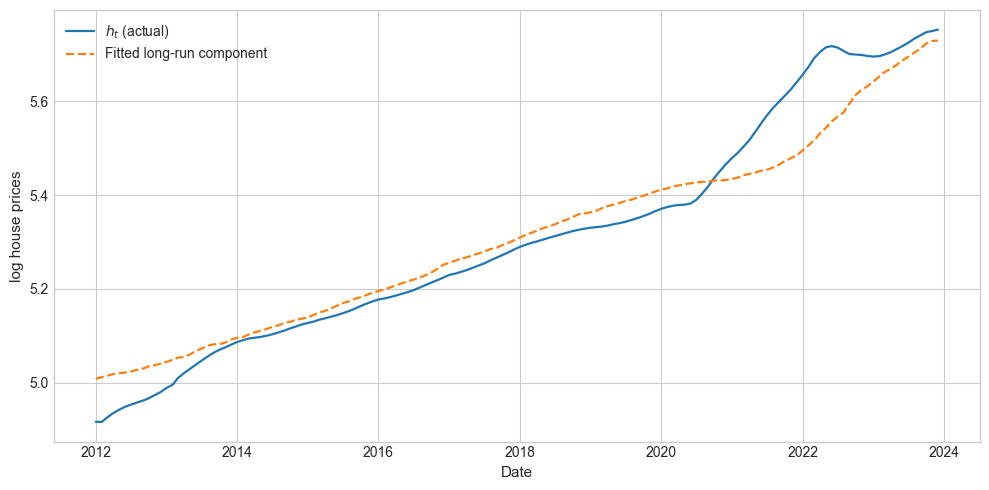

Saved: /Users/user/Projects/Econometrics-II/Assignment3/figures/fig2_cointegration_fit.pdf


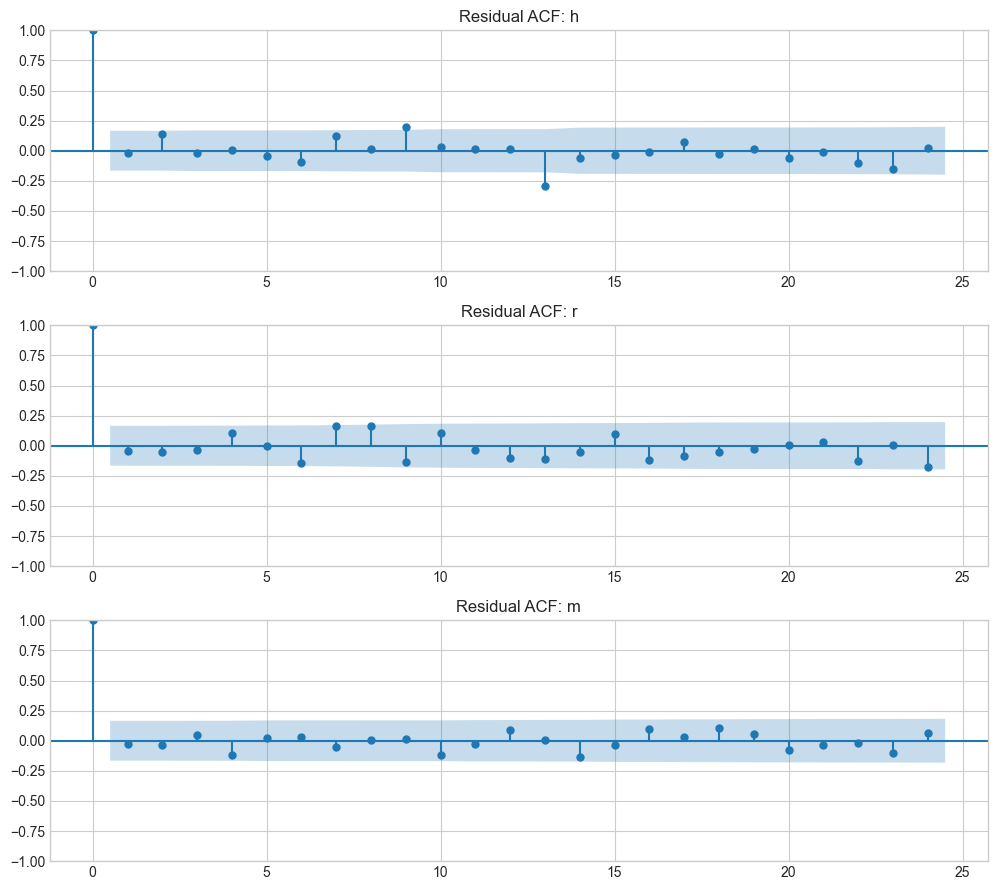

Saved: /Users/user/Projects/Econometrics-II/Assignment3/figures/fig3_residuals_acf.pdf


,Statistic,p-value
Test,,
Whiteness (Portmanteau),83.992264,3.011563e-01
Normality (Jarque--Bera),391.740128,1.667449e-81
ARCH LM (h),19.103691,8.605663e-02
ARCH LM (r),6.463579,8.909363e-01
ARCH LM (m),23.705328,2.230096e-02


In [10]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf

white = vecm_res.test_whiteness(nlags=12)
norm = vecm_res.test_normality()

diag_rows = [
    ("Whiteness (Portmanteau)", float(white.test_statistic), float(white.pvalue)),
    ("Normality (Jarque--Bera)", float(norm.test_statistic), float(norm.pvalue)),
]

resid = pd.DataFrame(vecm_res.resid, columns=["h", "r", "m"], index=core.index[-len(vecm_res.resid):])
for c in resid.columns:
    arch_stat, arch_p, _, _ = het_arch(resid[c], nlags=12)
    diag_rows.append((f"ARCH LM ({c})", float(arch_stat), float(arch_p)))

diag_df = pd.DataFrame(diag_rows, columns=["Test", "Statistic", "p-value"]).set_index("Test")

write_table(
    diag_df,
    TABLE_DIR / "table6_diagnostics.tex",
    caption="Misspecification diagnostics for the preferred CVAR specification.",
    label="tab:diagnostics",
    index_name="Test",
)
print("Saved:", TABLE_DIR / "table6_diagnostics.tex")

# Figure 2: actual h and fitted long-run component.
h_star_raw = beta_r * core["r"] + beta_m * core["m"]
offset = (core["h"] - h_star_raw).mean()
h_star = h_star_raw + offset

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(core.index, core["h"], label="$h_t$ (actual)", lw=1.6)
ax2.plot(core.index, h_star, label="Fitted long-run component", lw=1.6, linestyle="--")
ax2.set_xlabel("Date")
ax2.set_ylabel("log house prices")
ax2.legend()
fig2.tight_layout()
fig2_path = FIGURE_DIR / "fig2_cointegration_fit.pdf"
fig2.savefig(fig2_path, bbox_inches="tight")
plt.show()
print("Saved:", fig2_path)

# Figure 3: residual ACF by equation.
fig3, axes3 = plt.subplots(3, 1, figsize=(10, 9))
for i, c in enumerate(["h", "r", "m"]):
    plot_acf(resid[c], lags=24, ax=axes3[i])
    axes3[i].set_title(f"Residual ACF: {c}")
fig3.tight_layout()
fig3_path = FIGURE_DIR / "fig3_residuals_acf.pdf"
fig3.savefig(fig3_path, bbox_inches="tight")
plt.show()
print("Saved:", fig3_path)

diag_df

## 9) Robustness: full sample 2000M1--2023M12
Repeat the core analysis on the longer sample that includes the housing-boom and crisis years. Compare lag length, rank decision, the normalised long-run coefficients, and the LR test of $\beta_r=1$.

In [11]:
core_full = df_full.loc["2000-01-01":"2023-12-01", ["h", "r", "m"]].copy()
print("Full sample:", core_full.shape, core_full.index.min().date(), "to", core_full.index.max().date())

# Lag selection on full sample.
var_full = VAR(core_full)
lo_full = var_full.select_order(maxlags=12)
k_ar_full = int(lo_full.selected_orders.get("aic", 2))
k_ar_full = max(k_ar_full, 2)
k_ar_diff_full = k_ar_full - 1
print(f"Full-sample k_ar (AIC): {k_ar_full}")

# Johansen trace.
joh_full = coint_johansen(core_full, det_order=0, k_ar_diff=k_ar_diff_full)
trace_at_0_full = float(joh_full.lr1[0])
trace_at_1_full = float(joh_full.lr1[1])
cv_at_0_full = float(joh_full.cvt[0, 1])
cv_at_1_full = float(joh_full.cvt[1, 1])

rank_full = 0
for i in range(len(joh_full.lr1)):
    if joh_full.lr1[i] > joh_full.cvt[i, 1]:
        rank_full = i + 1
rank_full = max(rank_full, 1)

# VECM and normalised long-run coefficients.
vecm_full = VECM(core_full, k_ar_diff=k_ar_diff_full, coint_rank=1, deterministic="co").fit()
b_full = vecm_full.beta[:, 0]
beta_r_full = -b_full[1]
beta_m_full = -b_full[2]

# LR test of beta_r = 1 on the full sample.
lam_unr_full, T_full = johansen_with_restriction(core_full.values, k_ar_diff_full)
lam_res_full, _ = johansen_with_restriction(core_full.values, k_ar_diff_full, H_restr=H)
LR_full = float(abs(T_full * (np.log(1.0 - lam_res_full[0]) - np.log(1.0 - lam_unr_full[0])) * (-1.0)))
p_LR_full = float(1.0 - sstats.chi2.cdf(LR_full, df=1))

robust_table = pd.DataFrame({
    "2012M1--2023M12": [
        str(int(k_ar)),
        f"{float(joh.lr1[0]):.2f}",
        f"{float(joh.lr1[1]):.2f}",
        f"{beta_r:.4f}",
        f"{beta_m:.4f}",
        f"{LR_stat:.4f}",
        f"{p_value:.4f}",
    ],
    "2000M1--2023M12": [
        str(int(k_ar_full)),
        f"{trace_at_0_full:.2f}",
        f"{trace_at_1_full:.2f}",
        f"{beta_r_full:.4f}",
        f"{beta_m_full:.4f}",
        f"{LR_full:.4f}",
        f"{p_LR_full:.4f}",
    ],
}, index=[
    "VAR lag (AIC)",
    "Trace stat. at $r=0$",
    "Trace stat. at $r\\leq 1$",
    "$\\beta_r$",
    "$\\beta_m$",
    "LR stat. ($\\beta_r=1$)",
    "LR $p$-value",
])

write_table(
    robust_table,
    TABLE_DIR / "table8_robustness.tex",
    caption="Robustness of the main results to extending the sample to 2000M1--2023M12.",
    label="tab:robustness",
    index_name="Quantity",
    float_format="%s",
)
print(f"Full-sample beta_r = {beta_r_full:.4f}, beta_m = {beta_m_full:.4f}")
print(f"Full-sample LR(beta_r=1) = {LR_full:.4f}, p = {p_LR_full:.4f}")
print("Saved:", TABLE_DIR / "table8_robustness.tex")
robust_table

Full sample: (288, 3) 2000-01-01 to 2023-12-01
Full-sample k_ar (AIC): 4
Full-sample beta_r = 1.5521, beta_m = 0.1719
Full-sample LR(beta_r=1) = 2.7022, p = 0.1002
Saved: /Users/user/Projects/Econometrics-II/Assignment3/tables/table8_robustness.tex


/Users/user/Projects/Econometrics-II/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/user/Projects/Econometrics-II/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,2012M1--2023M12,2000M1--2023M12
VAR lag (AIC),4,4
Trace stat. at $r=0$,48.23,19.64
Trace stat. at $r\leq 1$,11.56,3.68
$\beta_r$,1.4918,1.5521
$\beta_m$,0.0085,0.1719
LR stat. ($\beta_r=1$),14.4616,2.7022
LR $p$-value,0.0001,0.1002
